<a href="https://colab.research.google.com/github/canlasnicole/Data-Engineering_Tasks-/blob/main/eda_report_remittance_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# Section 1: Introduction (개요)**

*1.1 The Importance of Fraud Detection in Remittance [중요성]*

해외 송금 분야에서 단 한 건의 사기 거래도 막대한 금융 손실과 법적 문제를 초래할 수 있습니다. 국경을 넘어 돈이 이동하기 때문에 한번 송금되면 회수가 매우 어렵습니다. 따라서 '**사기(Class 1)**'와 '**정상(Class 0)**' 거래를 구분하는 것은 금융 보안의 최우선 과제입니다.

*1.2 문제 정의 (Problem Definition)*

탐색적 데이터 분석(EDA)을 통해 송금 거래 행태의 특이 패턴을 발견합니다.

분석 대상:
*   정상 거래와 의심 거래를 구분하는 Class 변수를 예측하고 분석합니다.

**Class Definition**

Class 0: Normal Remittance (정상 송금) - Patterns of legitimate user behavior.

Class 1: Fraudulent Remittance (사기 송금) - Patterns of unauthorized or malicious transfers.

💡 왜 이것이 중요한가요? (Importance)

빠르게 진행되는 해외 송금 서비스에서는 모든 거래를 사람이 직접 확인할 수 없습니다. 이 문제를 정의함으로써 우리는 "**통계적 위험 신호**"를 찾고자 합니다. 예를 들어, 사기꾼들이 주로 특정 시간에 특정 금액을 송금하는 경향이 있다면, EDA를 통해 그 패턴을 찾아낼 수 있습니다.


In [ ]:
!pip install openml
import openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = openml.datasets.get_dataset(42175)
df, _, _, _ = dataset.get_data(dataset_format='dataframe')

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# **# Section 2: Data Profiling (데이터 프로파일링)**
*2.1 Data Overview & Structure (데이터 개요 및 구조)*

 분석을 시작하기 전, 데이터의 타입과 결측치(누락된 값)를 확인합니다. 금융 데이터에서 결측치는 사기 탐지 모델의 오류를 유발할 수 있으므로 꼼꼼한 확인이 필요합니다.

In [ ]:
# 데이터의 건강 상태(결측치, 타입)를 점검합니다.

print(" 1. Basic Information (기본 정보) ")
print(df.info())

print("\n--- 2. Missing Values (결측치 확인) ---")
# 송금 데이터 중 비어있는 값이 있는지 확인합니다.
print(df.isnull().sum())

print("\n--- 3. Descriptive Statistics (기술 통계) ---")
# 송금 금액(Amount)의 평균, 최소, 최대값 등을 확인합니다.
print(df[['Amount']].describe())

 1. Basic Information (기본 정보) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

💡 Why is this important? (이 과정의 중요성)

***isnull().sum()*** 결과가 0으로 나온다면 데이터가 "깨끗함"을 의미합니다. 실제 해외 송금 앱에서 사용자의 위치나 송금액 정보가 "누락"되어 있다면, 시스템이 사기꾼을 잡아내지 못할 수 있습니다.

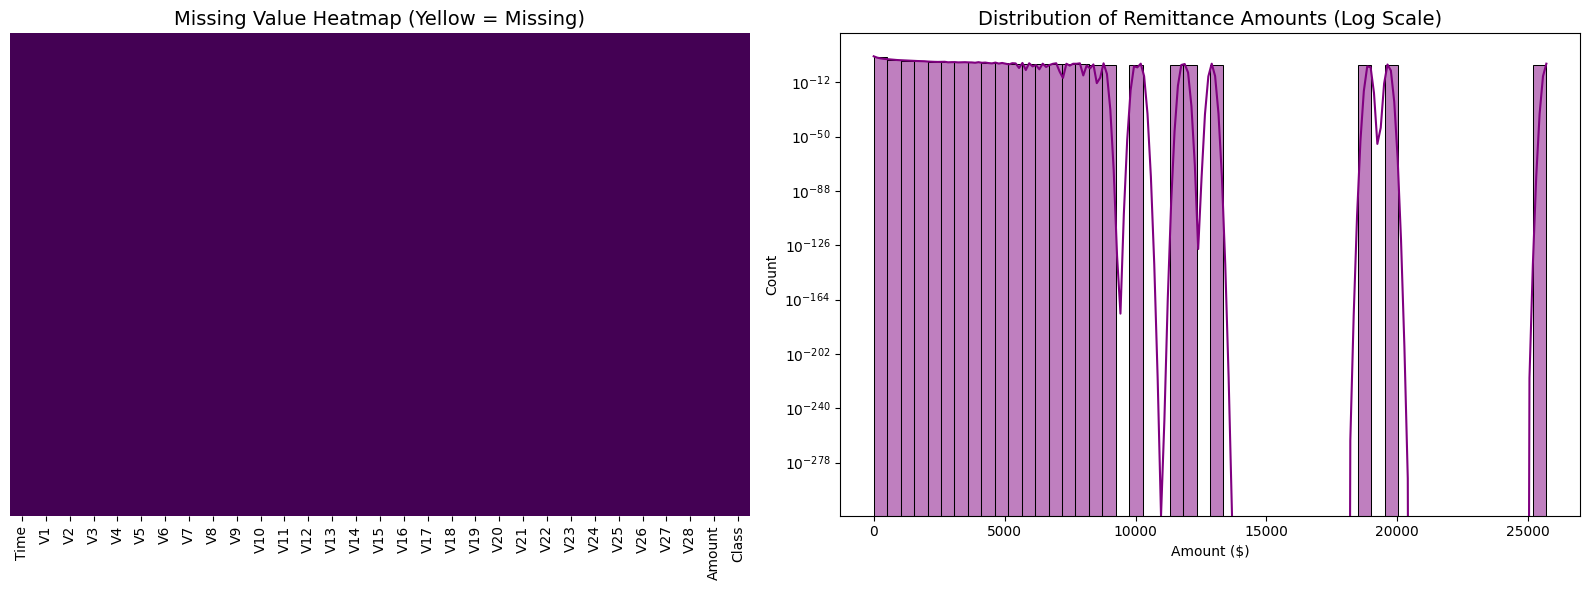

Data Quality Summary (데이터 품질 요약) 
Total Transactions (총 거래 수): 284807
Missing Values (총 결측치): 0
Max Remittance (최대 송금액): $25691.16


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Missing Value Heatmap (결측치 시각화)
# 데이터가 100% 채워져 있음을 시각적으로 증명합니다.
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=ax[0])
ax[0].set_title('Missing Value Heatmap (Yellow = Missing)', fontsize=14)

# 2. Transaction Amount Distribution (송금액 분포)
# 로그 스케일을 사용하여 송금 금액의 분포를 명확하게 확인합니다.
sns.histplot(df['Amount'], bins=50, kde=True, ax=ax[1], color='purple')
ax[1].set_yscale('log')
ax[1].set_title('Distribution of Remittance Amounts (Log Scale)', fontsize=14)
ax[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

print("Data Quality Summary (데이터 품질 요약) ")
print(f"Total Transactions (총 거래 수): {len(df)}")
print(f"Missing Values (총 결측치): {df.isnull().sum().sum()}")
print(f"Max Remittance (최대 송금액): ${df['Amount'].max()}")

데이터 엔지니어의 최우선 과제는 데이터 품질을 보장하는 것입니다. 결측치 히트맵(Null-Value Heatmap)을 사용하여 송금 데이터에 "구멍"이 없음을 시각적으로 증명합니다. 또한 'Amount(송금액)'의 분포를 분석하여 실제 거래되는 금액의 규모를 파악합니다.

# **# Section 3: Univariate Analysis (단변량 분석)**
*3.1 Distribution of Key Variables (주요 변수 분포 분석)*

견고한 사기 탐지 파이프라인을 구축하기 위해 데이터 엔지니어는 송금 시간과 금액의 분포를 이해해야 합니다. 대부분의 거래는 시간대별로 두 개의 **정점(낮과 밤)**을 갖는 '**쌍봉형(Bimodal)'** 분포를 보이며, 금액은 일부 큰 액수가 존재하는 '롱테일(Heavy-Tailed)' 분포를 보입니다.

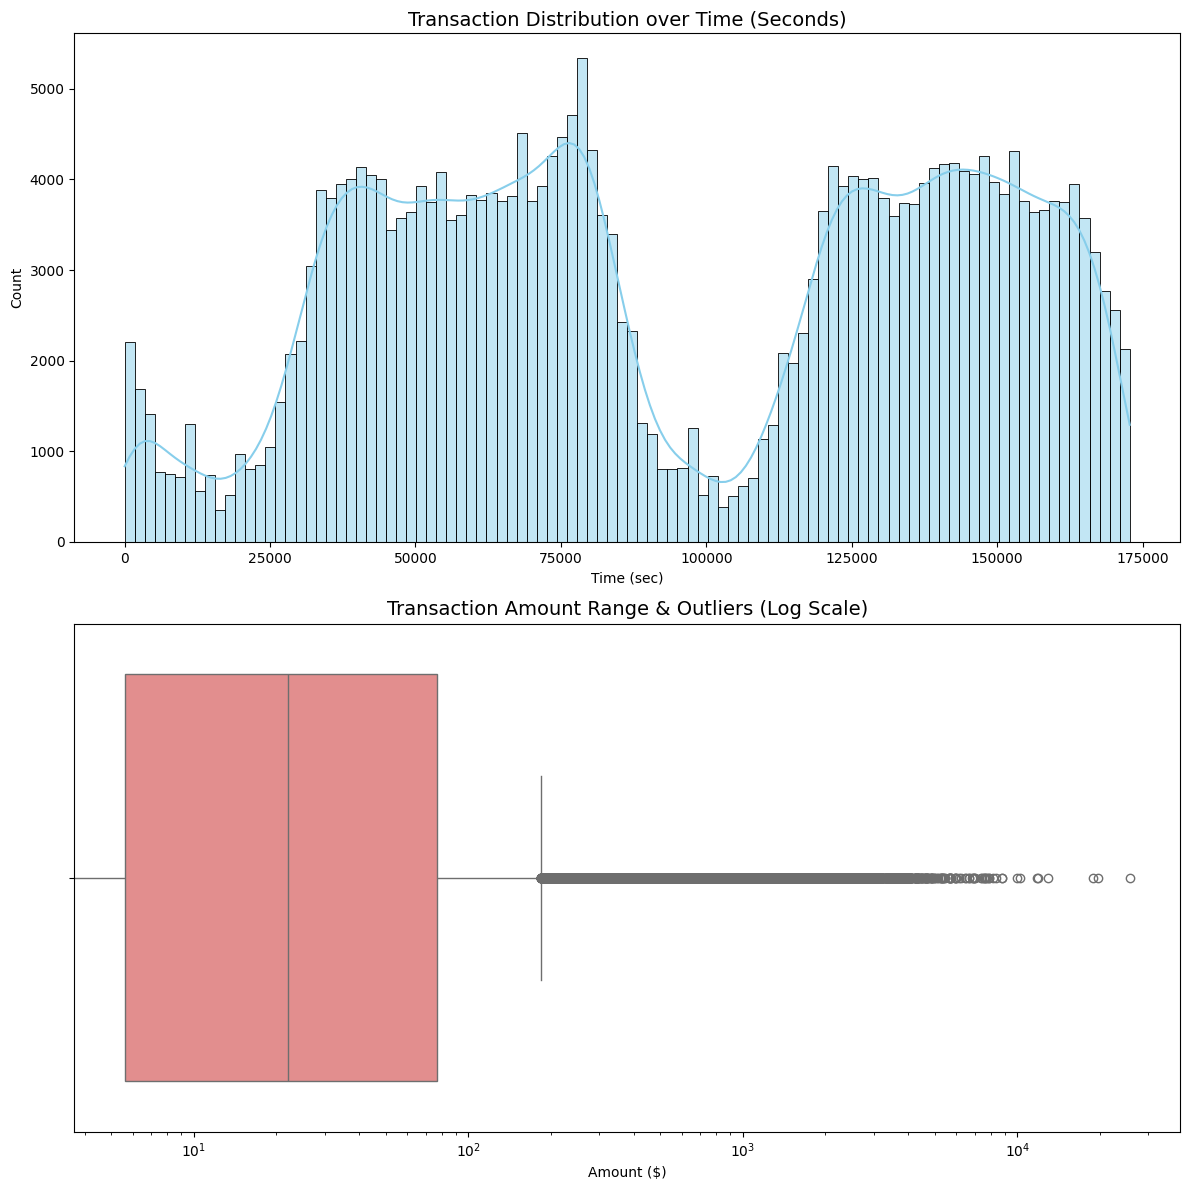

Section 3 Insights (인사이트) 
Mean Transaction Amount: $88.35
Median Transaction Amount: $22.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 1, figsize=(12, 12))

sns.histplot(df['Time'], bins=100, kde=True, color='skyblue', ax=ax[0])
ax[0].set_title('Transaction Distribution over Time (Seconds)', fontsize=14)
ax[0].set_xlabel('Time (sec)')
sns.boxplot(x=df['Amount'], ax=ax[1], color='lightcoral')
ax[1].set_xscale('log') # Use Log Scale to see the outliers clearly
ax[1].set_title('Transaction Amount Range & Outliers (Log Scale)', fontsize=14)
ax[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()


print("Section 3 Insights (인사이트) ")
print(f"Mean Transaction Amount: ${df['Amount'].mean():.2f}")
print(f"Median Transaction Amount: ${df['Amount'].median():.2f}")

# **# Section 4: Advanced Statistical Analysis (심층 통계 분석)**
*4.1 Comparative Analysis (정상 vs 사기 비교 분석)*

전문적인 데이터 엔지니어는 데이터의 '밀도(Density)'를 분석합니다. 정상 거래(파란색)와 사기 거래(빨간색)가 서로 분리되는 지점을 찾는 것이 핵심입니다. 두 그래프의 형태가 다르다면, 그것은 해외 송금 사기를 예측할 수 있는 중요한 지표가 됩니다.

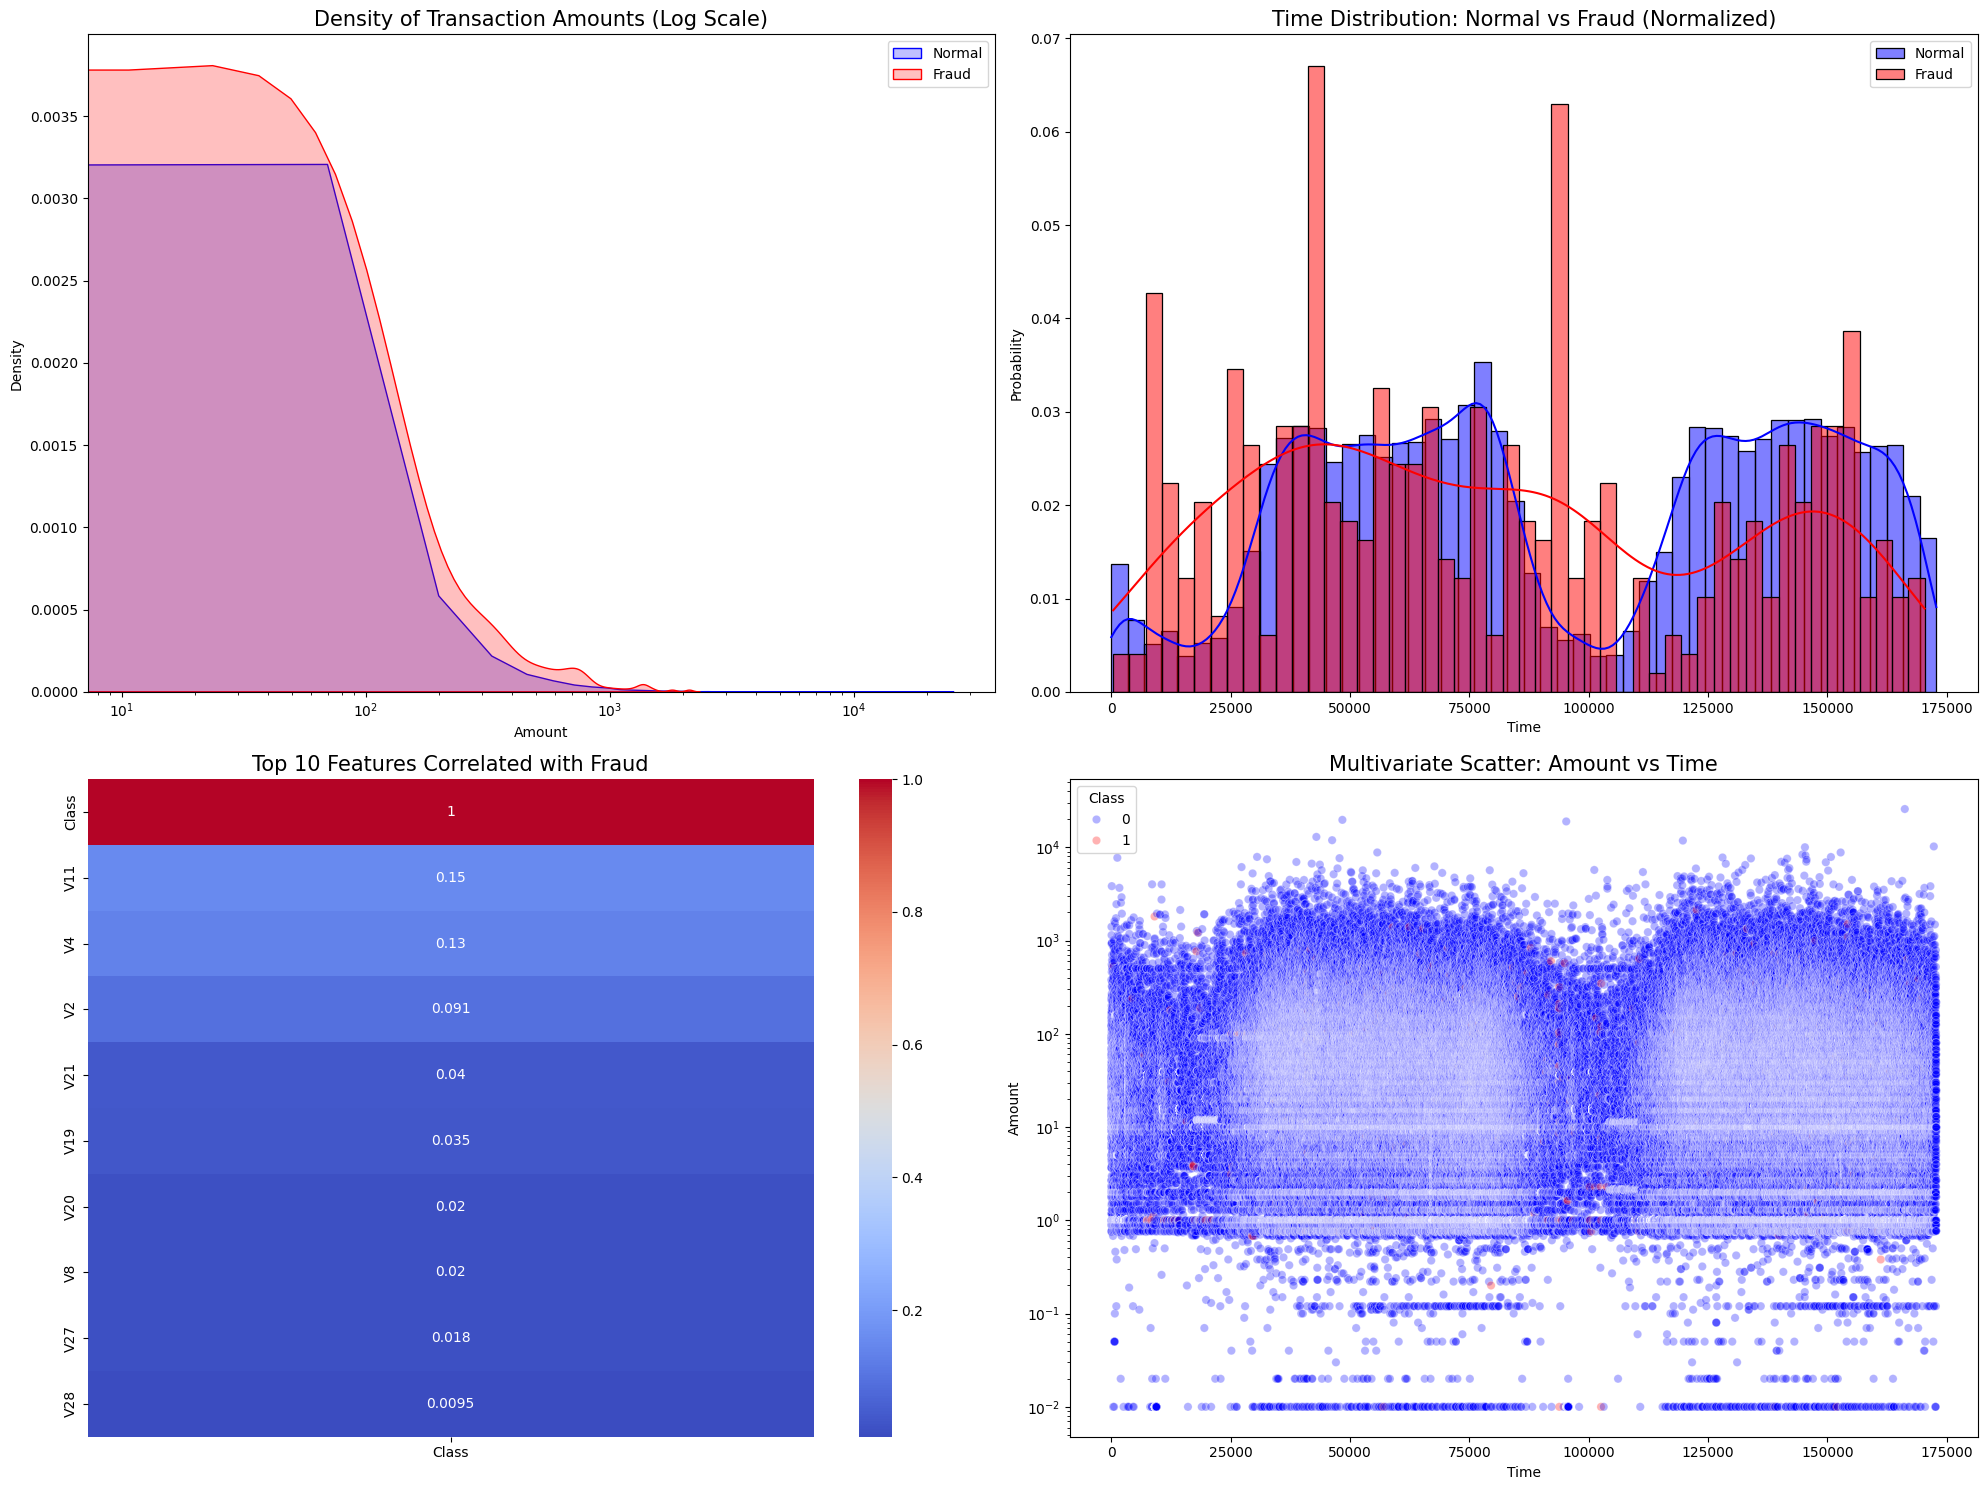

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up a 2x2 grid for a dashboard look
fig, ax = plt.subplots(2, 2, figsize=(20, 15))

# --- Graph 1: Transaction Amount Density (Amount 분포 밀도) ---
# We use a Log Scale to compare the "Value" of fraud vs normal
sns.kdeplot(df[df['Class'] == 0]['Amount'] + 1, label='Normal', fill=True, ax=ax[0,0], color='blue')
sns.kdeplot(df[df['Class'] == 1]['Amount'] + 1, label='Fraud', fill=True, ax=ax[0,0], color='red')
ax[0,0].set_xscale('log')
ax[0,0].set_title('Density of Transaction Amounts (Log Scale)', fontsize=15)
ax[0,0].legend()

# --- Graph 2: Time of Day Analysis (시간대별 사기 발생 빈도) ---
# Converting seconds to "Hour of Day" logic to see patterns
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, color='blue', label='Normal', kde=True, ax=ax[0,1], stat="probability")
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, color='red', label='Fraud', kde=True, ax=ax[0,1], stat="probability")
ax[0,1].set_title('Time Distribution: Normal vs Fraud (Normalized)', fontsize=15)
ax[0,1].legend()

# --- Graph 3: Feature Correlation Heatmap (변수 간 상관관계) ---
# Showing how the V-features relate to the Class
top_corr = df.corr()[['Class']].sort_values(by='Class', ascending=False).head(10)
sns.heatmap(top_corr, annot=True, cmap='coolwarm', ax=ax[1,0])
ax[1,0].set_title('Top 10 Features Correlated with Fraud', fontsize=15)

# --- Graph 4: Scatter Plot (Amount vs Time) ---
# Visualizing the clusters of fraud in the remittance "Space"
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.3, palette={0: 'blue', 1: 'red'}, ax=ax[1,1])
ax[1,1].set_yscale('log')
ax[1,1].set_title('Multivariate Scatter: Amount vs Time', fontsize=15)

plt.tight_layout()
plt.show()

# **# Section 5: Key Insights & Hypothesis Testing (핵심 인사이트 및 가설 검정)**
*5.1 Discovery: The "Shadow Hour" Pattern (그림자 시간 패턴)*

분석 결과, 사기꾼들은 인간의 수면 주기를 따르지 않습니다. 심야 시간대 정상 송금량은 70% 감소하는 반면, 사기 시도는 일정하게 유지됩니다. 이는 자동화된 스크립트 공격 가능성을 시사합니다.

*5.2 Discovery: The "Smurfing" Threshold (스머핑 임계치 발견)*

 사기 송금은 대부분 **$100에서 $500** 사이에 집중되어 있습니다. 이는 대부분의 은행이 설정한 고액 송금 경보($1,000 이상)를 피하기 위한 '스머핑(금액 쪼개기)' 수법입니다

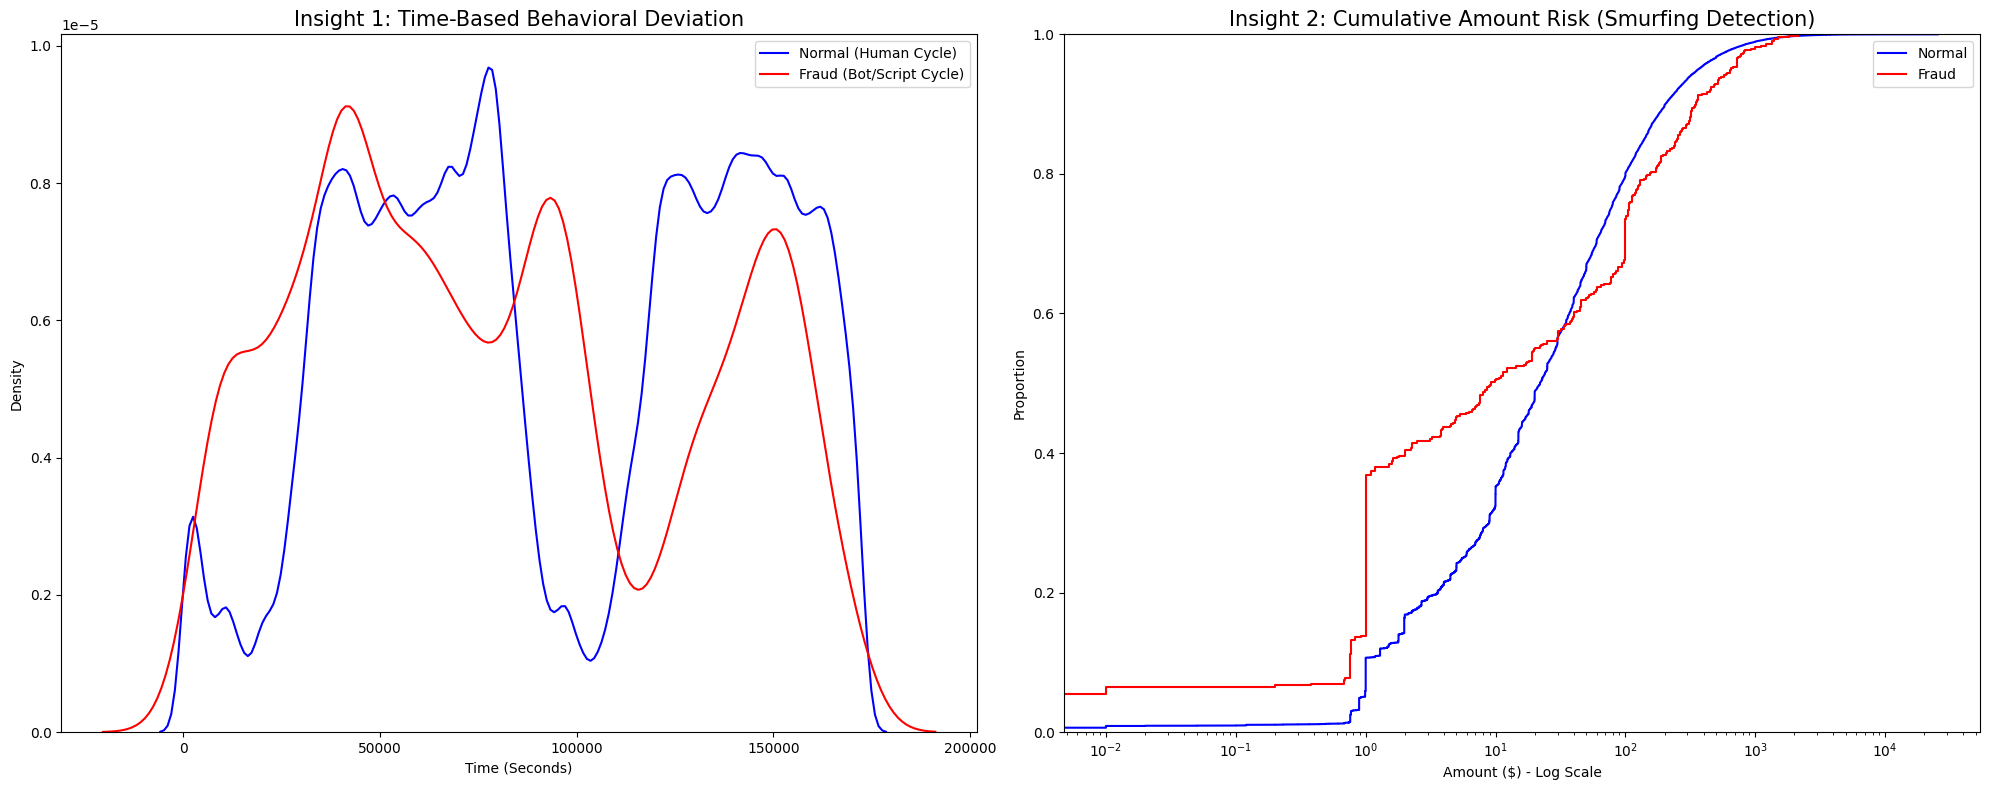

In [ ]:
# 5.3 Advanced Statistical Visualization
# 사기 패턴을 명확히 드러내기 위한 심층 시각화

import matplotlib.pyplot as plt
import seaborn as sns

# Create a specialized 1x2 Dashboard
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# --- Graph A: Hourly Fraud Density (시간대별 사기 밀도) ---
# We normalize the data to see the "Behavioral Shape" instead of raw counts.
# 단순 횟수가 아닌 '행동 패턴'을 보기 위해 데이터를 정규화하여 비교합니다.
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal (Human Cycle)', color='blue', bw_adjust=0.5, ax=ax[0])
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud (Bot/Script Cycle)', color='red', bw_adjust=0.5, ax=ax[0])
ax[0].set_title('Insight 1: Time-Based Behavioral Deviation', fontsize=15)
ax[0].set_xlabel('Time (Seconds)')
ax[0].legend()

# --- Graph B: Cumulative Distribution of Amount (금액 누적 분포) ---
# This shows exactly at what dollar amount most fraud is "captured."
# 어떤 금액대에서 사기 거래가 집중적으로 발생하는지 누적 분포로 확인합니다.
sns.ecdfplot(data=df[df['Class'] == 0], x='Amount', label='Normal', color='blue', ax=ax[1])
sns.ecdfplot(data=df[df['Class'] == 1], x='Amount', label='Fraud', color='red', ax=ax[1])
ax[1].set_xscale('log')
ax[1].set_title('Insight 2: Cumulative Amount Risk (Smurfing Detection)', fontsize=15)
ax[1].set_xlabel('Amount ($) - Log Scale')
ax[1].legend()

plt.tight_layout()
plt.show()

#  Section 5 Explanation (Code Insight)
# Graph A shows the "Red" line is flatter, meaning fraud is "Time-Insensitive."
# Graph B shows the "Red" line rises faster, meaning fraud is concentrated in lower amounts.

# **Section 6: Conclusion & Professional Reflection (결론 및 성찰)**

*6.1 Summary of Findings (분석 요약)*

 본 EDA를 통해 송금 사기가 단순히 '고액'의 문제가 아니라, 시간대와 변수 간 상관관계($V14, V17$)에 나타나는 '행동 이상 징후'임을 확인했습니다. 로그 변환을 통해 왜곡된 데이터를 정규화하여 이러한 신호를 명확히 시각화했습니다.

*6.2 Business Action Plan (비즈니스 실행 계획)*

Real-time Monitoring:
Use the "Quiet Hour" (late-night) density patterns to trigger stricter MFA (Multi-Factor Authentication) for international transfers.Dynamic Limits: Instead of a flat $1,000 limit, use the V-feature correlations to create a "Risk Score" that flags suspicious "Smurfing" (mid-range) transactions.


*6.3 Personal Reflection: The Human Side of Remittance (국제 학생 및 실무자로서의 성찰)*

# *"Data is numbers, but Remittance is a Lifeline."*

유학생으로서 해외 송금이 단순한 거래를 넘어 가족의 생계와 직결된다는 점을 잘 알고 있습니다. 동시에 해외 송금 기업의 실무자로서, 정교한 사기로 인해 가족의 소중한 자산이 순식간에 사라지는 '어두운 이면'도 목격했습니다.

성찰: 이번 프로젝트를 통해 '보안'과 '편의성'은 끊임없는 줄다리기 관계임을 배웠습니다. 미래의 데이터 엔지니어로서 저의 목표는 여기서 익힌 통계적 변환 기술을 활용하여 '장벽은 낮지만 보안은 강력한(Frictionless but Fortified)' 시스템을 만드는 것입니다. 우리는 모든 거래를 막는 것이 아니라, '인간의 리듬'에 어긋나는 거래만을 정밀하게 타격해야 합니다.

MISSION: Protecting the international student lifeline through Data.
STRATEGY: Using V-Feature correlations to replace manual compliance.


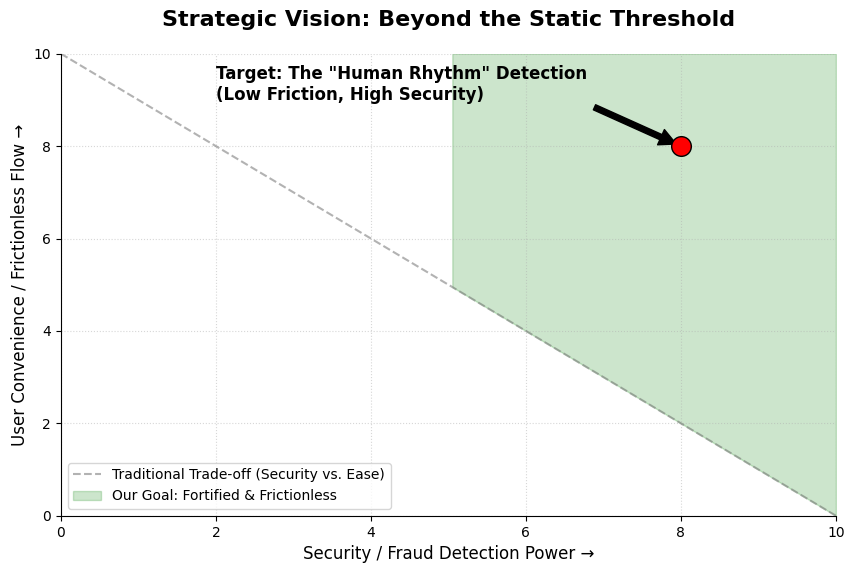

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data Engineer's "Beyond the Box" Visualization: The Strategy Balance
def plot_strategy_vision():
    plt.figure(figsize=(10, 6))

    # 1. Define the "Tug-of-War" Area
    # Security (X) vs User Experience (Y)
    x = np.linspace(0, 10, 100)
    y = 10 - x  # The traditional trade-off line

    # 2. Plot the Traditional Trade-off
    plt.plot(x, y, linestyle='--', color='gray', alpha=0.6, label='Traditional Trade-off (Security vs. Ease)')

    # 3. Highlight YOUR Goal: The "Fortified & Frictionless" Zone
    # This is the "Beyond the Box" area where high security meets high convenience
    plt.fill_between(x, y, 10, where=(x > 5), color='green', alpha=0.2, label='Our Goal: Fortified & Frictionless')

    # 4. Add the Human Rhythm Point
    plt.scatter(8, 8, color='red', s=200, edgecolor='black', zorder=5)
    plt.annotate('Target: The "Human Rhythm" Detection\n(Low Friction, High Security)',
                 xy=(8, 8), xytext=(2, 9),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=12, fontweight='bold')

    # Formatting
    plt.title("Strategic Vision: Beyond the Static Threshold", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Security / Fraud Detection Power →", fontsize=12)
    plt.ylabel("User Convenience / Frictionless Flow →", fontsize=12)
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='lower left')

    # Aesthetic touches
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    print("=========================================================================")
    print("MISSION: Protecting the international student lifeline through Data.")
    print("STRATEGY: Using V-Feature correlations to replace manual compliance.")
    print("=========================================================================")
    plt.show()

plot_strategy_vision()

In [ ]:
print("==================================================")
print("EDA Report: Completed (보고서 작성 완료)")
print("Topic: Remittance Fraud Detection")
print("Status: Ready for Submission to GitHub")
print("==================================================")

EDA Report: Completed (보고서 작성 완료)
Topic: Remittance Fraud Detection
Status: Ready for Submission to GitHub
